In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)

In [2]:
cpu_df = pd.read_csv(
    "../data/Processed/cpu_master.csv"
)

In [4]:
# convert timestamp
cpu_df["ts"] = pd.to_datetime(
    cpu_df["ts"],
    format="mixed",
    utc=True
)

In [5]:
cpu_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74285 entries, 0 to 74284
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   id                74285 non-null  int64              
 1   ts                74285 non-null  datetime64[ns, UTC]
 2   host_id           74285 non-null  int64              
 3   cpu_usage_pct     74285 non-null  float64            
 4   memory_usage_pct  74285 non-null  float64            
 5   power_kw          74285 non-null  float64            
 6   status            74285 non-null  object             
 7   hostName          74285 non-null  object             
 8   ilo_server_id     74285 non-null  int64              
 9   inlet_temp_c      74285 non-null  int64              
 10  cpu_temp_c        74285 non-null  int64              
 11  processor_count   74285 non-null  int64              
dtypes: datetime64[ns, UTC](1), float64(3), int64(6), object(2)
m

In [6]:
# missing values analysis
cpu_df.isnull().sum()

id                  0
ts                  0
host_id             0
cpu_usage_pct       0
memory_usage_pct    0
power_kw            0
status              0
hostName            0
ilo_server_id       0
inlet_temp_c        0
cpu_temp_c          0
processor_count     0
dtype: int64

In [7]:
# duplicate check
cpu_df.duplicated().sum()

np.int64(0)

In [8]:
# Status distribution
cpu_df["status"].value_counts()

status
Normal      72604
Warning      1671
Critical       10
Name: count, dtype: int64

In [10]:
cpu_df["status_encoded"] = (
    cpu_df["status"]
    .map({
        "Normal":0,
        "Warning":1,
        "Critical":2
    })
)

cpu_df.head()

,id,ts,host_id,cpu_usage_pct,memory_usage_pct,power_kw,status,hostName,ilo_server_id,inlet_temp_c,cpu_temp_c,processor_count,status_encoded
0,2,2026-04-02 12:22:07.517000+00:00,2,17.0,70.0,0.245,Normal,10.10.10.150,2,20,43,2,0
1,5,2026-04-02 12:24:02.882000+00:00,2,16.0,70.0,0.263,Normal,10.10.10.150,2,20,44,2,0
2,8,2026-04-02 12:26:01.700000+00:00,2,15.0,70.0,0.256,Normal,10.10.10.150,2,21,44,2,0
3,11,2026-04-02 12:28:01.845000+00:00,2,16.0,70.0,0.251,Normal,10.10.10.150,2,20,44,2,0
4,14,2026-04-02 12:30:02.091000+00:00,2,16.0,70.0,0.260,Normal,10.10.10.150,2,20,45,2,0


In [12]:
# timestamp storing
cpu_df = cpu_df.sort_values(
    ["hostName","ts"]
)
# reset index
cpu_df = cpu_df.reset_index(drop=True)

In [14]:
# Check CPU range
cpu_df["cpu_usage_pct"].describe()

count    74285.000000
mean        13.419627
std         11.510434
min          1.000000
25%          2.000000
50%          9.000000
75%         27.000000
max        100.000000
Name: cpu_usage_pct, dtype: float64

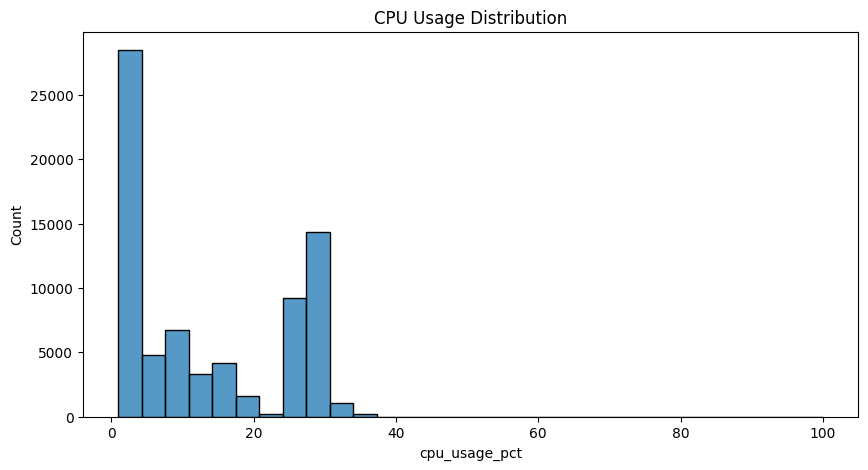

In [16]:
# CPU distribution plot
plt.figure(figsize=(10,5))

sns.histplot(
    cpu_df["cpu_usage_pct"],
    bins=30
)

plt.title("CPU Usage Distribution")
plt.show()

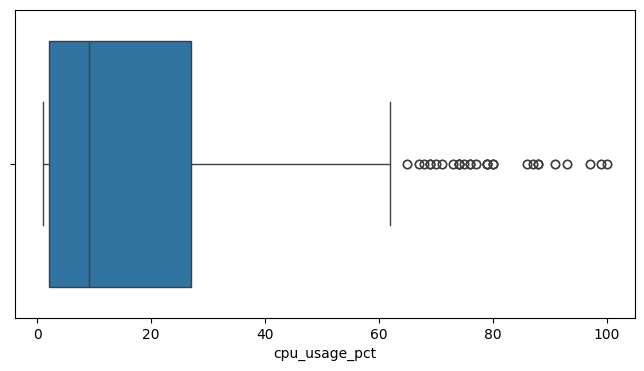

In [18]:
# Boxplot
plt.figure(figsize=(8,4))

sns.boxplot(
    x=cpu_df["cpu_usage_pct"]
)

plt.show()

In [19]:
# Outlier detection
Q1 = cpu_df["cpu_usage_pct"].quantile(0.25)

Q3 = cpu_df["cpu_usage_pct"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR

upper = Q3 + 1.5*IQR

print(lower)
print(upper)

-35.5
64.5


In [20]:
# Count outliers
outliers = cpu_df[
    (cpu_df["cpu_usage_pct"] < lower)
    |
    (cpu_df["cpu_usage_pct"] > upper)
]

print(len(outliers))

58


In [21]:
# Check sampling interval
genai = cpu_df[
    cpu_df["hostName"] ==
    cpu_df["hostName"].unique()[0]
]

# calculate interval
genai["ts"].diff().value_counts()

ts
0 days 00:02:00           69
0 days 00:02:00.001000    44
0 days 00:01:59.998000    25
0 days 00:02:00.003000    24
0 days 00:01:59.999000    22
                          ..
0 days 00:05:01.026000     1
0 days 00:01:20.511000     1
0 days 00:02:22.188000     1
0 days 00:02:52.249000     1
0 days 00:04:57.984000     1
Name: count, Length: 12698, dtype: int64

In [23]:
genai["ts"].diff().describe()

count                        24761
mean     0 days 00:04:03.102933403
std      0 days 00:01:23.892296644
min         0 days 00:00:59.829000
25%         0 days 00:02:01.414000
50%         0 days 00:04:58.859000
75%         0 days 00:05:00.547000
max         0 days 00:11:41.618000
Name: ts, dtype: object

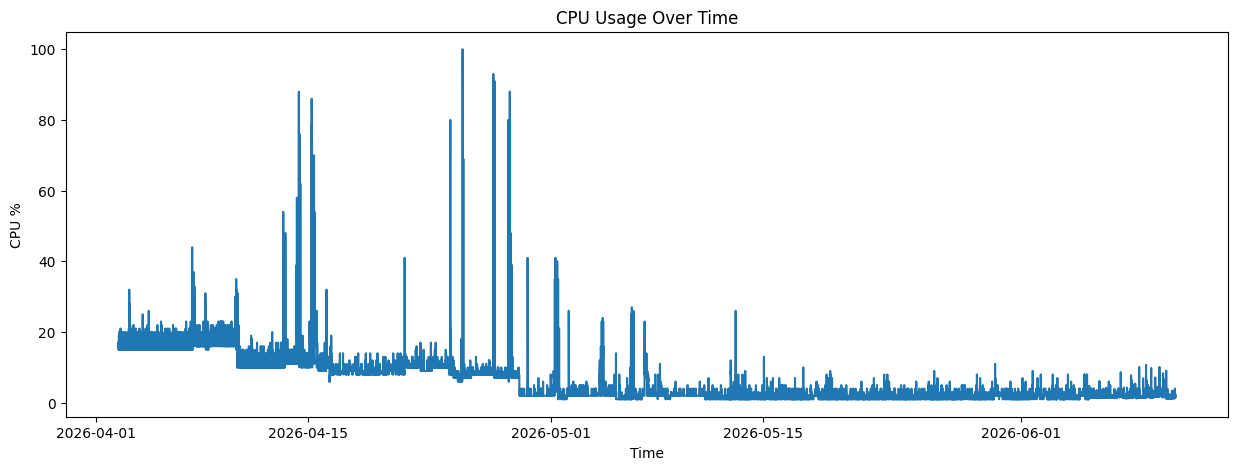

In [24]:
# Visualize CPU trends
plt.figure(figsize=(15,5))

plt.plot(
    genai["ts"],
    genai["cpu_usage_pct"]
)

plt.title("CPU Usage Over Time")
plt.xlabel("Time")
plt.ylabel("CPU %")

plt.show()

In [25]:
# server wise count
cpu_df.groupby(
    "hostName"
)["cpu_usage_pct"].count()

hostName
10.10.10.150    24762
10.10.10.2      24762
10.10.10.65     24761
Name: cpu_usage_pct, dtype: int64

In [30]:
cpu_cleaned = cpu_df.copy()

cpu_cleaned = cpu_cleaned.drop(
    columns=["ilo_server_id"]
)

In [31]:
cpu_cleaned.to_csv(
    "../data/Processed/cpu_cleaned.csv",
    index=False
)

In [32]:
cpu_cleaned.columns

Index(['id', 'ts', 'host_id', 'cpu_usage_pct', 'memory_usage_pct', 'power_kw',
       'status', 'hostName', 'inlet_temp_c', 'cpu_temp_c', 'processor_count',
       'status_encoded'],
      dtype='object')

In [ ]:
# average cpu usage per server
avg_cpu = (
    cpu_df.groupby(["host_id", "hostName"])["cpu_usage_pct"]
    .mean()
    .reset_index()
)

avg_cpu["cpu_usage_pct"] = avg_cpu["cpu_usage_pct"].round(2)

print("Average CPU Usage Per Server")
print("-" * 50)

for _, row in avg_cpu.iterrows():
    print(
        f"Host ID   : {row['host_id']}\n"
        f"Host Name : {row['hostName']}\n"
        f"Average CPU Usage : {row['cpu_usage_pct']}%\n"    
    )

Average CPU Usage Per Server
--------------------------------------------------
Host ID   : 1
Host Name : 10.10.10.65
Average CPU Usage : 4.41%

Host ID   : 2
Host Name : 10.10.10.150
Average CPU Usage : 7.79%

Host ID   : 3
Host Name : 10.10.10.2
Average CPU Usage : 28.07%

